In [14]:
# 🔷 0. INSTALL & IMPORT

!pip install kagglehub --quiet

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

In [15]:
# 🔷 1. DOWNLOAD DATASET

print("Downloading dataset...")
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Dataset Path:", path)

100%|██████████| 42.6M/42.6M [00:00<00:00, 120MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2


In [16]:
# 🔷 2. LOAD DATA

orders = pd.read_csv(f"{path}/olist_orders_dataset.csv")
customers = pd.read_csv(f"{path}/olist_customers_dataset.csv")
items = pd.read_csv(f"{path}/olist_order_items_dataset.csv")
products = pd.read_csv(f"{path}/olist_products_dataset.csv")
payments = pd.read_csv(f"{path}/olist_order_payments_dataset.csv")
reviews = pd.read_csv(f"{path}/olist_order_reviews_dataset.csv")
category = pd.read_csv(f"{path}/product_category_name_translation.csv")

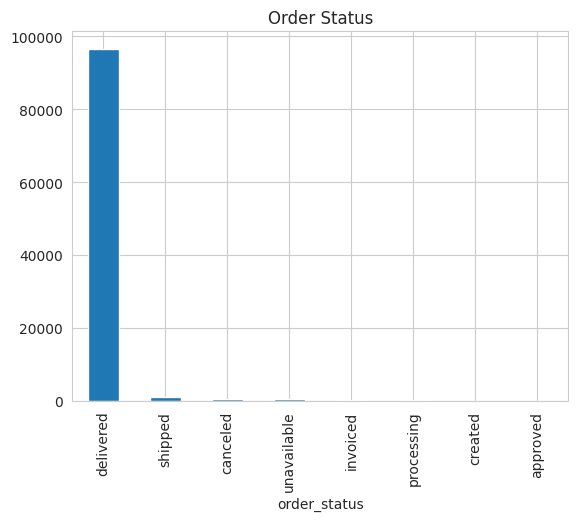

In [17]:
# 🔷 3. QUICK GRAPHS FOR EACH DATASET

# Orders by status
orders['order_status'].value_counts().plot(kind='bar', title="Order Status")
plt.show()

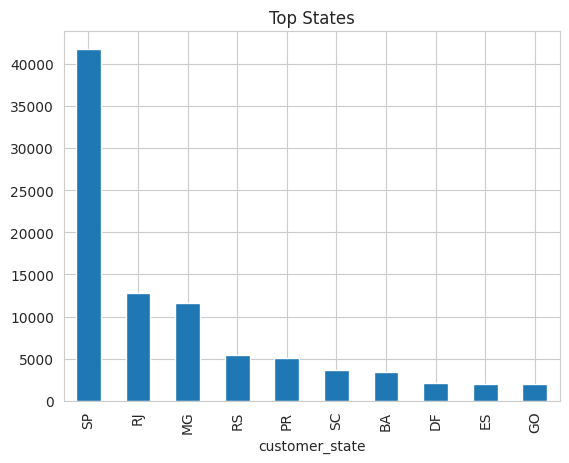

In [18]:
# Customer states
customers['customer_state'].value_counts().head(10).plot(kind='bar', title="Top States")
plt.show()

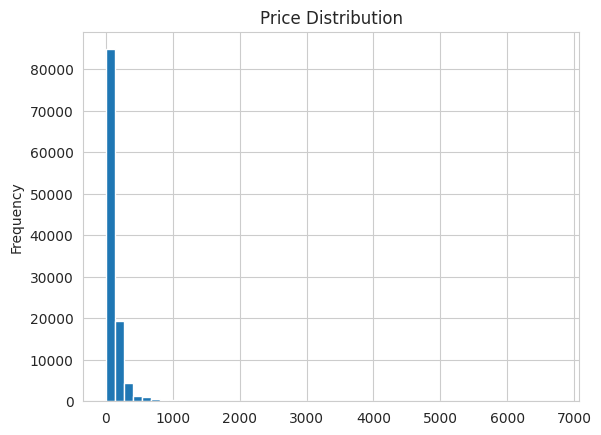

In [19]:
# Price distribution (FIXED ERROR)
items['price'].dropna().plot(kind='hist', bins=50, title="Price Distribution")
plt.show()

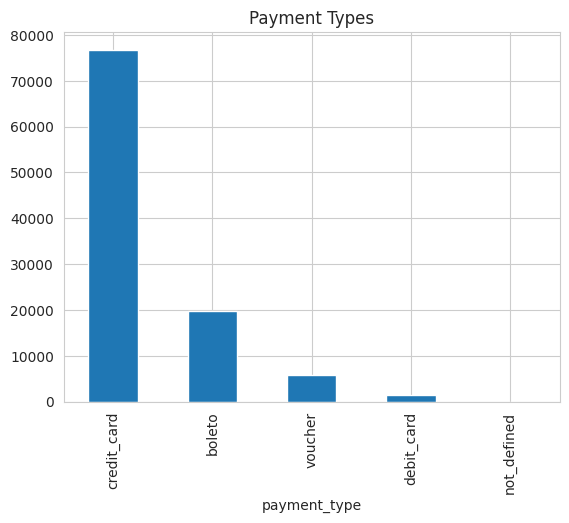

In [20]:
# Payment types
payments['payment_type'].value_counts().plot(kind='bar', title="Payment Types")
plt.show()

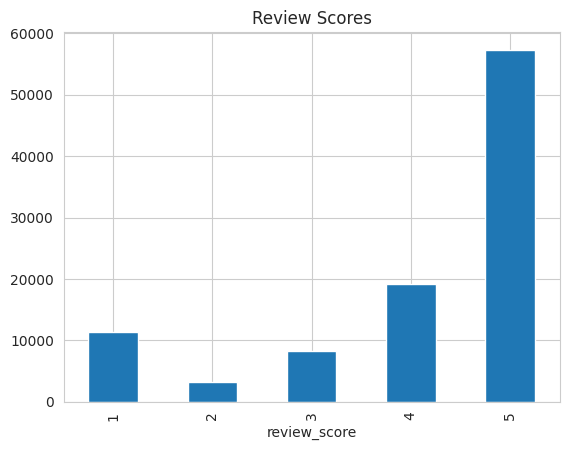

In [21]:
# Review scores
reviews['review_score'].value_counts().sort_index().plot(kind='bar', title="Review Scores")
plt.show()

In [22]:
# 🔷 4. MERGE DATA


df = orders.merge(customers[['customer_id','customer_state']], on='customer_id', how='left')

df.rename(columns={
    'customer_state':'state',
    'order_purchase_timestamp':'order_date'
}, inplace=True)

df['order_date'] = pd.to_datetime(df['order_date'])

# Revenue
payment_agg = payments.groupby('order_id')['payment_value'].sum().reset_index()
payment_agg.rename(columns={'payment_value':'revenue'}, inplace=True)
df = df.merge(payment_agg, on='order_id', how='left')

# Reviews
review_agg = reviews.groupby('order_id')['review_score'].median().reset_index()
df = df.merge(review_agg, on='order_id', how='left')

# Categories
item_prod = items.merge(products[['product_id','product_category_name']], on='product_id', how='left')
item_prod = item_prod.merge(category, on='product_category_name', how='left')

cat = item_prod.groupby('order_id')['product_category_name_english']\
      .agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan).reset_index()

cat.rename(columns={'product_category_name_english':'category'}, inplace=True)
df = df.merge(cat, on='order_id', how='left')

In [23]:
# 🔷 5. CLEANING

df['review_score'].fillna(df['review_score'].median(), inplace=True)
df['state'].fillna('Unknown', inplace=True)
df = df[df['revenue'] > 0]
df.drop_duplicates(inplace=True)

In [24]:
# 🔷 6. FEATURE ENGINEERING

df['month'] = df['order_date'].dt.to_period('M')
df['year'] = df['order_date'].dt.year

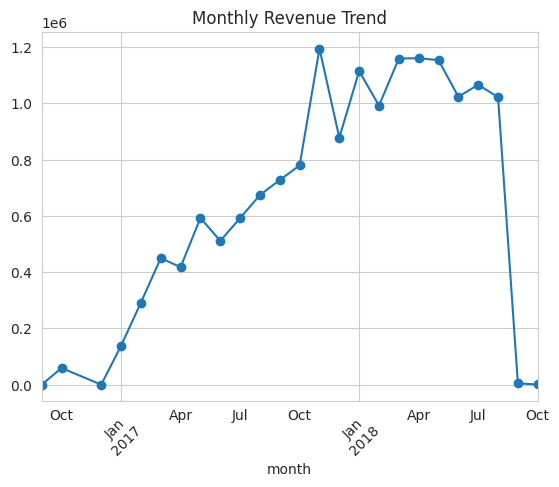

In [25]:
# 🔷 7. MONTHLY REVENUE GRAPH

monthly = df.groupby('month')['revenue'].sum()

monthly.plot(marker='o', title="Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.show()

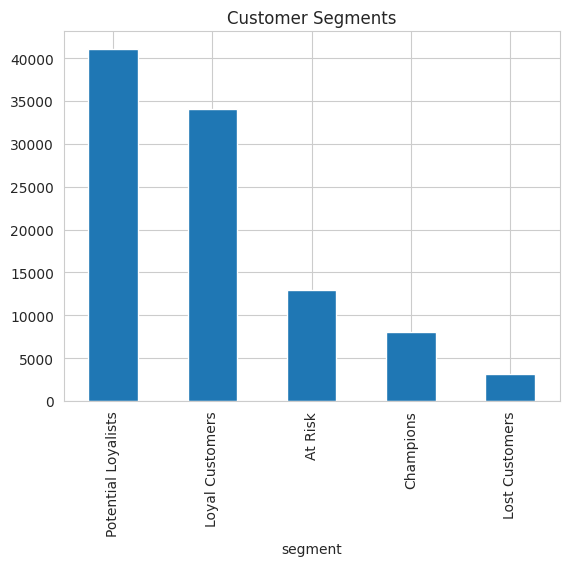

In [26]:
# 🔷 8. RFM ANALYSIS

ref_date = df['order_date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    recency=('order_date', lambda x: (ref_date - x.max()).days),
    frequency=('order_id','nunique'),
    monetary=('revenue','sum')
).reset_index()

rfm['R'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1], duplicates='drop')
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M'] = pd.qcut(rfm['monetary'], 5, labels=[1,2,3,4,5])

rfm['score'] = rfm[['R','F','M']].astype(int).sum(axis=1)

def segment(x):
    if x >= 13: return "Champions"
    elif x >= 10: return "Loyal Customers"
    elif x >= 7: return "Potential Loyalists"
    elif x >= 5: return "At Risk"
    else: return "Lost Customers"

rfm['segment'] = rfm['score'].apply(segment)

# Segment Plot
rfm['segment'].value_counts().plot(kind='bar', title="Customer Segments")
plt.show()

In [27]:
# 🔷 9. REPORT METRICS EXTRACTION

# Revenue metrics
total_revenue = df['revenue'].sum()
total_orders = df['order_id'].nunique()
total_customers = df['customer_id'].nunique()
aov = df['revenue'].mean()

peak_month = monthly.idxmax().strftime('%B')

# RFM
segment_counts = rfm['segment'].value_counts()
segment_share = (segment_counts / total_customers * 100).round(1)

at_risk = segment_counts.get('At Risk', 0)
lost = segment_counts.get('Lost Customers', 0)

# Category
top_category = df.groupby('category')['revenue'].sum().idxmax()

# Geography
top_states = df['state'].value_counts().head(3)

# Payments
payment_share = payments['payment_type'].value_counts(normalize=True)*100
payment_share = payment_share.round(1)

# Reviews
positive = (df['review_score'] >= 4).mean()*100
negative = (df['review_score'] <= 2).mean()*100

In [28]:
# 🔷 10. FINAL INSIGHTS OUTPUT

print("\n📋 INSIGHTS SUMMARY REPORT")
print("="*50)

print("\n🔷 Revenue Performance")
print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Unique Customers: {total_customers}")
print(f"AOV: {aov:.2f}")
print(f"Peak Month: {peak_month}")

print("\n🔷 Customer Segments")
for seg in segment_counts.index:
    print(f"{seg}: {segment_counts[seg]} ({segment_share[seg]}%)")

print(f"\nAt Risk + Lost Customers: {at_risk + lost}")

print("\n🔷 Top Category:", top_category)

print("\n🔷 Top States")
print(top_states)

print("\n🔷 Payment Share (%)")
print(payment_share)

print("\n🔷 Customer Satisfaction")
print(f"4–5 Stars: {positive:.1f}%")
print(f"1–2 Stars: {negative:.1f}%")

# ✅ DONE


📋 INSIGHTS SUMMARY REPORT

🔷 Revenue Performance
Total Revenue: 16,008,872.12
Total Orders: 99437
Unique Customers: 99437
AOV: 161.00
Peak Month: November

🔷 Customer Segments
Potential Loyalists: 41069 (41.3%)
Loyal Customers: 34122 (34.3%)
At Risk: 12964 (13.0%)
Champions: 8104 (8.1%)
Lost Customers: 3178 (3.2%)

At Risk + Lost Customers: 16142

🔷 Top Category: health_beauty

🔷 Top States
state
SP    41742
RJ    12852
MG    11635
Name: count, dtype: int64

🔷 Payment Share (%)
payment_type
credit_card    73.9
boleto         19.0
voucher         5.6
debit_card      1.5
not_defined     0.0
Name: proportion, dtype: float64

🔷 Customer Satisfaction
4–5 Stars: 77.2%
1–2 Stars: 14.5%
